## Evaluate ERA-Interim Cross validation


In [25]:
import os
import sys

import numpy as np
import pandas as pd
import xarray as xr
import colorcet as cc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

base_dir = os.path.dirname(os.path.abspath('')).split(os.sep + 'eval_transferability')[0]

colors = sns.color_palette('colorblind')

In [13]:
MODEL_SPEC = 'ERAI'
DATA_SPEC = 'ERAI'

ds_clim = xr.open_dataset(os.path.sep.join([base_dir, 'data', 'interim', DATA_SPEC, 'HIRHAM5', 'firnpack', 'climat_1990-2016_smoothed15.nc']))
snmel_clim = ds_clim['snmel']

pred_dir = os.path.sep.join([base_dir, 'output', f'crossvalyears_{MODEL_SPEC}_modularNNEBM_log'])

fig_dir = os.path.sep.join([base_dir, 'figures', 'crossvalidation', f'model{MODEL_SPEC}_data{DATA_SPEC}'])
os.makedirs(fig_dir, exist_ok=True)

if MODEL_SPEC == DATA_SPEC:
    FILE_SPEC = ''
else:
    FILE_SPEC = '_' + DATA_SPEC
    
chunking = {'time': 366, 'y': -1, 'x': -1}

## Load data

In [6]:
output_file = os.path.sep.join([pred_dir, f'scores_per_year{FILE_SPEC}.csv'])
df_per_year = pd.read_csv(output_file, index_col=[0,1,2])
df_per_year

true melt  predicted melt   residual  residual_rel  \
valyear iter appliedyear                                                       
1992    0    1990             576.0           582.0   5.391816      0.009361   
             1991             547.0           561.0  13.426325      0.024545   
             1992             294.0           349.0  55.733401      0.189569   
             1993             570.0           587.0  16.928896      0.029700   
             1994             476.0           501.0  25.261444      0.053070   
...                             ...             ...        ...           ...   
2016    4    2012            1059.0          1080.0  21.221164      0.020039   
             2013             510.0           553.0  43.098448      0.084507   
             2014             650.0           683.0  32.846364      0.050533   
             2015             611.0           676.0  65.124756      0.106587   
             2016             726.0           755.0  29.073233      0.040046   

                              RMSE         RMSEn       MAE         MAEn  \
valyear iter appliedyear                                                  
1992    0    1990         0.860925  31839.924893  0.170540  6307.148900   
             1991         0.848496  33048.908305  0.167545  6525.872616   
             1992         0.768258  55915.264996  0.133305  9702.204023   
             1993         0.740591  27684.196577  0.158523  5925.784044   
             1994         0.698603  31292.069351  0.140793  6306.441106   
...                            ...           ...       ...          ...   
2016    4    2012         0.896552  18096.982988  0.203069  4098.977379   
             2013         0.880558  36785.578490  0.143220  5983.054903   
             2014         0.835122  27374.841501  0.151288  4959.132534   
             2015         1.003879  35025.276458  0.177287  6185.533510   
             2016         0.893279  26312.294702  0.171291  5045.532793   

                               MBE         MBEn  ...  residual_leq1  \
valyear iter appliedyear                         ...                  
1992    0    1990         0.008222   304.094499  ...      41.853035   
             1991         0.020475   797.502041  ...      42.774841   
             1992         0.084761  6169.034756  ...      43.163936   
             1993         0.025816   965.045077  ...      40.810915   
             1994         0.038523  1725.555217  ...      38.719681   
...                            ...          ...  ...            ...   
2016    4    2012         0.032274   651.446915  ...      20.413892   
             2013         0.065725  2745.673884  ...      29.387636   
             2014         0.050090  1641.937136  ...      20.681188   
             2015         0.099315  3465.085132  ...      29.328145   
             2016         0.044215  1302.398391  ...      24.327004   

                          residual_leq50  residual_g50  RMSE_debiased  \
valyear iter appliedyear                                                
1992    0    1990             -35.939689     -0.521512       0.860885   
             1991             -29.232278     -0.116191       0.848249   
             1992              12.510171      0.059275       0.763568   
             1993             -23.573764     -0.308331       0.740141   
             1994             -13.121452     -0.336832       0.697540   
...                                  ...           ...            ...   
2016    4    2012              -0.331443      1.138689       0.895971   
             2013              13.333148      0.377710       0.878102   
             2014              11.365051      0.800131       0.833619   
             2015              34.938556      0.858075       0.998954   
             2016               4.622626      0.123583       0.892184   

                          best_mbe  best_mae  best_rmse  best_mbe_allyears  \
valyear iter appliedyear                                 

In [7]:
scaling_factor = 1.796553703424 / 58391
df_per_year.loc[:,'total AE'] = df_per_year['MAE'] * scaling_factor * 58391 * 365.25     # MAE converted to total Gt per year
df_per_year.loc[:,'AE_rel'] = df_per_year['total AE'] / df_per_year['true melt']

In [8]:
df_per_year[df_per_year['best_mbe_allyears']].agg(['mean', 'std']).iloc[:,:15]

,true melt,predicted melt,residual,residual_rel,RMSE,RMSEn,MAE,MAEn,MBE,MBEn,R2,R2_anomalies,residual_leq1,residual_leq50,residual_g50
mean,620.629630,624.410256,3.724290,0.009851,0.830288,29695.047082,0.154490,5423.683854,0.005671,320.418643,0.964271,0.867026,27.022090,-22.944908,-0.352895
std,138.138707,132.098415,21.085612,0.039129,0.080104,6272.494467,0.026604,834.840283,0.032142,1272.074735,0.008591,0.030410,7.794651,20.441471,0.686717


In [77]:
output_file = os.path.sep.join([pred_dir, f'scores_per_year{FILE_SPEC}.csv'])
df_per_year = pd.read_csv(output_file, index_col=[0,1,2])
df_per_year

true melt  predicted melt   residual  residual_rel  \
valyear iter appliedyear                                                       
1992    0    1990             576.0           582.0   5.391816      0.009361   
             1991             547.0           561.0  13.426325      0.024545   
             1992             294.0           349.0  55.733401      0.189569   
             1993             570.0           587.0  16.928896      0.029700   
             1994             476.0           501.0  25.261444      0.053070   
...                             ...             ...        ...           ...   
2016    4    2012            1059.0          1080.0  21.221164      0.020039   
             2013             510.0           553.0  43.098448      0.084507   
             2014             650.0           683.0  32.846364      0.050533   
             2015             611.0           676.0  65.124756      0.106587   
             2016             726.0           755.0  29.073233      0.040046   

                              RMSE         RMSEn       MAE         MAEn  \
valyear iter appliedyear                                                  
1992    0    1990         0.860925  31839.924893  0.170540  6307.148900   
             1991         0.848496  33048.908305  0.167545  6525.872616   
             1992         0.768258  55915.264996  0.133305  9702.204023   
             1993         0.740591  27684.196577  0.158523  5925.784044   
             1994         0.698603  31292.069351  0.140793  6306.441106   
...                            ...           ...       ...          ...   
2016    4    2012         0.896552  18096.982988  0.203069  4098.977379   
             2013         0.880558  36785.578490  0.143220  5983.054903   
             2014         0.835122  27374.841501  0.151288  4959.132534   
             2015         1.003879  35025.276458  0.177287  6185.533510   
             2016         0.893279  26312.294702  0.171291  5045.532793   

                               MBE         MBEn  ...  residual_leq1  \
valyear iter appliedyear                         ...                  
1992    0    1990         0.008222   304.094499  ...      41.853035   
             1991         0.020475   797.502041  ...      42.774841   
             1992         0.084761  6169.034756  ...      43.163936   
             1993         0.025816   965.045077  ...      40.810915   
             1994         0.038523  1725.555217  ...      38.719681   
...                            ...          ...  ...            ...   
2016    4    2012         0.032274   651.446915  ...      20.413892   
             2013         0.065725  2745.673884  ...      29.387636   
             2014         0.050090  1641.937136  ...      20.681188   
             2015         0.099315  3465.085132  ...      29.328145   
             2016         0.044215  1302.398391  ...      24.327004   

                          residual_leq50  residual_g50  RMSE_debiased  \
valyear iter appliedyear                                                
1992    0    1990             -35.939689     -0.521512       0.860885   
             1991             -29.232278     -0.116191       0.848249   
             1992              12.510171      0.059275       0.763568   
             1993             -23.573764     -0.308331       0.740141   
             1994             -13.121452     -0.336832       0.697540   
...                                  ...           ...            ...   
2016    4    2012              -0.331443      1.138689       0.895971   
             2013              13.333148      0.377710       0.878102   
             2014              11.365051      0.800131       0.833619   
             2015              34.938556      0.858075       0.998954   
             2016               4.622626      0.123583       0.892184   

                          best_mbe  best_mae  best_rmse  best_mbe_allyears  \
valyear iter appliedyear                                 

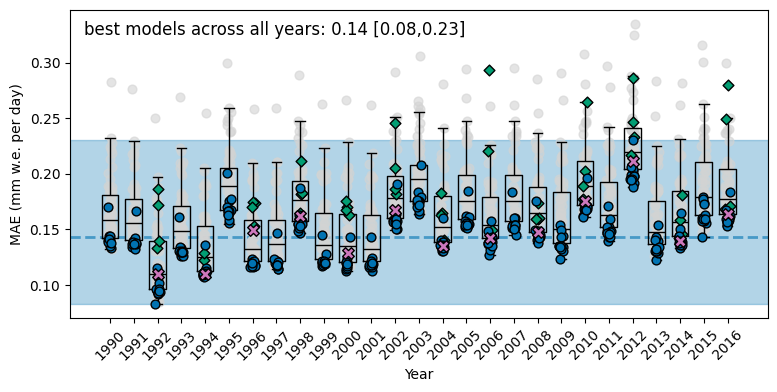

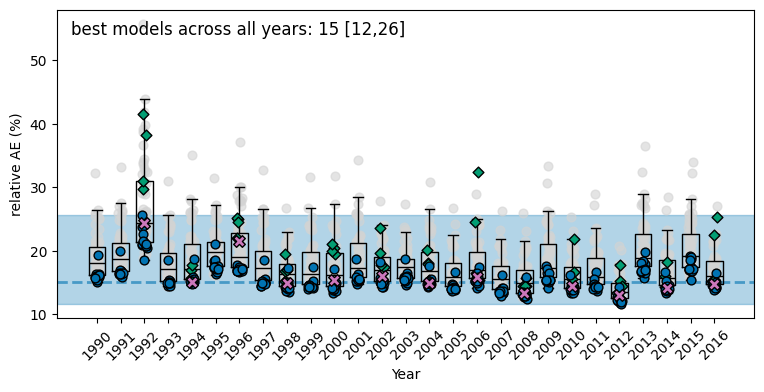

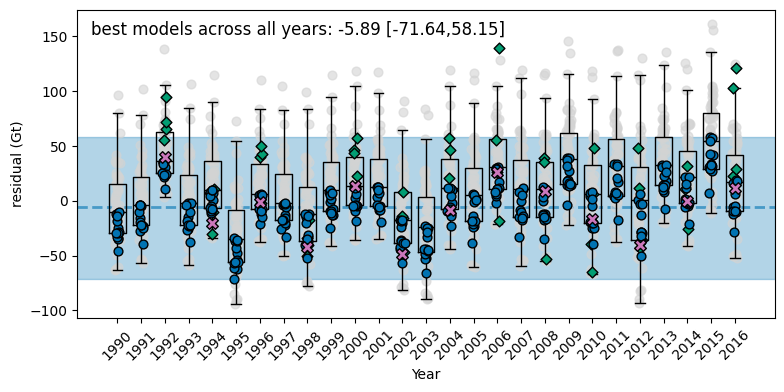

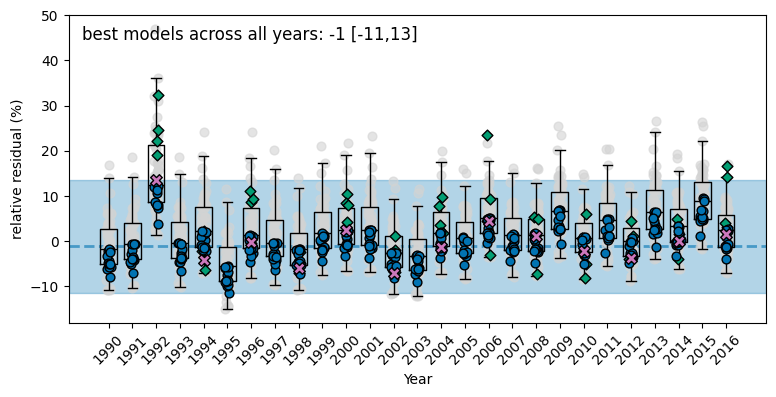

In [ ]:
# # Performance of all models: plot per year
# blue: best models of other folds
# green: models which were validated on the same year as they were applied (i.e. validation year = applied year)
# red: best one among the green ones
PLOT_TRUE = False
PLOT_SPREAD = True
HIGHLIGHT = 'best_mae_allyears'   # or 'best_mbe', 'best_mbe_allyears', 'best_rmse'

appliedyears = range(1990, 2017)
valyears = range(1992, 2017, 2)
# Plot of residuals per year in Gt

true_melt = df_per_year[df_per_year.index.get_level_values('iter') == 0][['true melt']].droplevel(level=[0,1])
melt_max = int(round(true_melt.max().item()*1.1,0))

for metric_to_plot in ['MAE', 'AE_rel', 'residual', 'residual_rel']:
    fig, ax = plt.subplots(figsize=(9,4))
    
    if PLOT_TRUE:
        ax2 = ax.twinx()
        # ax.set_zorder(ax2.get_zorder()+1)
        ax.patch.set_visible(False) 
        ax2.step(x=range(len(true_melt)), y=true_melt.values, where='mid', color='k', linewidth=1.2, linestyle=':')
        ax2.set_ylim((0, melt_max))
        ax2.set_ylabel('True annual melt (Gt)')

    if PLOT_SPREAD:
        med_val = df_per_year[df_per_year[HIGHLIGHT]][metric_to_plot].agg('median')
        min_val, max_val = (df_per_year[df_per_year[HIGHLIGHT]][metric_to_plot].agg(['min', 'max']))
        
        if '_rel' in metric_to_plot:
            med_val *= 100
            min_val *= 100
            max_val *= 100
            ax.axhline(y=med_val, color=colors[0], alpha=0.6, linestyle='--', linewidth=2, zorder=-5)
            ax.axhspan(ymin=min_val, ymax=max_val, color=colors[0], alpha=0.3, zorder=-5)
            ax.text(0.02, 0.92, f'best models across all years: {med_val:.0f} [{min_val:.0f},{max_val:.0f}]', transform=ax.transAxes, fontsize=12)
        else:
            ax.axhline(y=med_val, color=colors[0], alpha=0.6, linestyle='--', linewidth=2, zorder=-5)
            ax.axhspan(ymin=min_val, ymax=max_val, color=colors[0], alpha=0.3, zorder=-5)
            ax.text(0.02, 0.92, f'best models across all years: {med_val:.2f} [{min_val:.2f},{max_val:.2f}]', transform=ax.transAxes, fontsize=12)

    for i,bb in enumerate(appliedyears): 
        dff = df_per_year.xs(bb, level='appliedyear')[[metric_to_plot, HIGHLIGHT]]

        if '_rel' in metric_to_plot:
            dff[metric_to_plot] = dff[metric_to_plot]*100
        
        vp = sns.boxplot(dff[metric_to_plot].values, positions=[i], showfliers=False, widths=0.7, fill=False, color='k', linewidth=1, ax=ax, zorder=-1)

        
        dff_nonh = dff[(dff.index.get_level_values('valyear') != bb) & (~dff[HIGHLIGHT])]
            
        dff_val = dff[(dff.index.get_level_values('valyear') == bb) & (~dff[HIGHLIGHT])]
        
        dff_best = dff[(dff.index.get_level_values('valyear') != bb) & (dff[HIGHLIGHT])]
        
        dff_best_val = dff[(dff.index.get_level_values('valyear') == bb) & (dff[HIGHLIGHT])]

        ax.scatter((np.random.rand(len(dff_nonh)))*0.2+i-0.1, dff_nonh[metric_to_plot].values, s=40, color='lightgrey', alpha=0.6, zorder=-5)
        ax.scatter((np.random.rand(len(dff_val)))*0.2+i-0.1, dff_val[metric_to_plot].values, s=30, marker='D', color=colors[2], edgecolor='k', linewidth=1, zorder=1)
        ax.scatter((np.random.rand(len(dff_best)))*0.2+i-0.1, dff_best[metric_to_plot].values, s=40, color=colors[0], edgecolor='k', linewidth=1, zorder=1)
        ax.scatter([i]*len(dff_best_val), dff_best_val[metric_to_plot].values, s=70, marker='X', color=colors[4], edgecolor='k', linewidth=1, zorder=1)

        ax.set_xticks(np.arange(len(appliedyears)))
        ax.set_xticklabels(appliedyears, rotation=45)       

        if metric_to_plot=='R2':
            ax.set_ylabel('R$²$')
        elif metric_to_plot=='R2_anomalies':
            ax.set_ylabel('R$²_{anom}$')
        elif 'rel' in metric_to_plot:
            ax.set_ylabel(f'relative {metric_to_plot.split("_rel")[0]} (%)')
        elif 'residual' in metric_to_plot:
            ax.set_ylabel(f'{metric_to_plot} (Gt)')
        else:
            ax.set_ylabel(metric_to_plot+' (mm w.e. per day)')
        ax.set_xlabel('Year')
        
        # fig.savefig(os.path.sep.join([fig_dir, f"per_year_{metric_to_plot}_{HIGHLIGHT}.png"]), bbox_inches='tight', dpi=200)
        fig.savefig(os.path.sep.join([fig_dir, f"per_year_{metric_to_plot}_{HIGHLIGHT}.pdf"]), bbox_inches='tight')

    plt.show()

## OTHER PLOTS

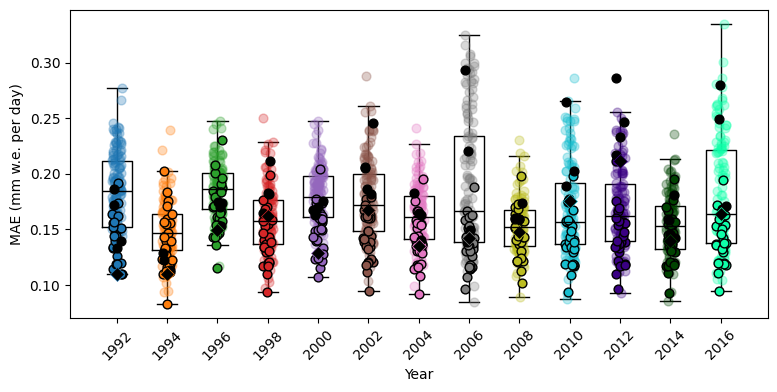

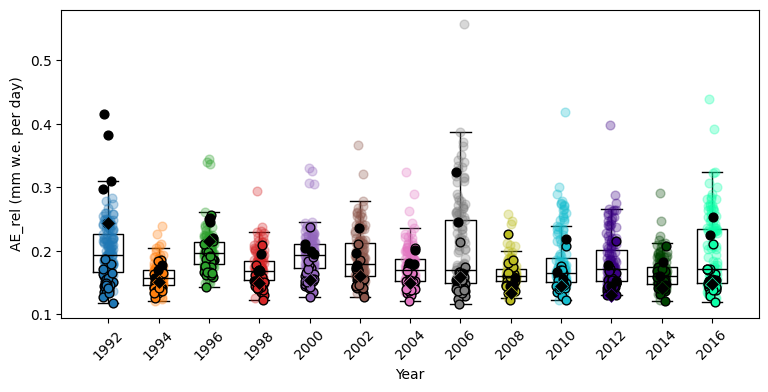

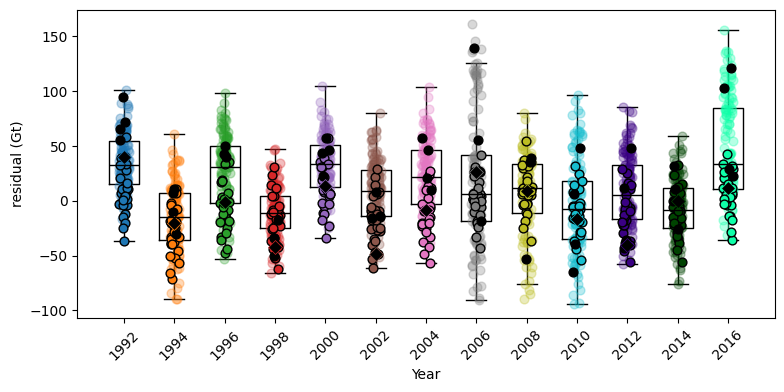

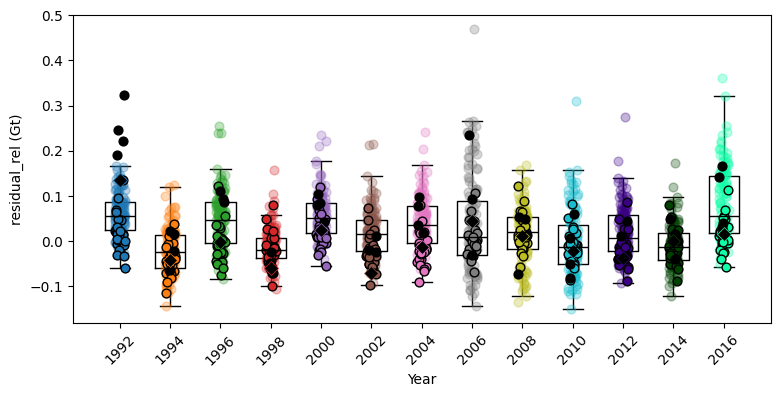

In [ ]:
## Performance of all models: plot per model (=fold=validation year)
# for each fold, the scores on all applied years are plotted
# scores of the other years (!=validation year) of the non-best model are in color without outline
# scores of the other years (!=validation year) of the best model are in color with outline
# scores of the validation year of the non-best model are indicated as black dots
# score of the validation year of the best model is indicated as black diamond

PLOT_TRUE = False
HIGHLIGHT = 'best_mae_allyears'   # or 'best_mbe', 'best_mbe_allyears', 'best_rmse'

import seaborn as sns
cmap = mcolors.ListedColormap(cc.glasbey_category10)
colors = cmap.colors

appliedyears = range(1990, 2017)
valyears = range(1992, 2017, 2)
# Plot of residuals per year in Gt

true_melt = df_per_year[df_per_year.index.get_level_values('iter') == 0][['true melt']].droplevel(level=[0,1])
melt_max = int(round(true_melt.max().item()*1.1,0))

metrics = ['MAE', 'AE_rel', 'residual', 'residual_rel']

for metric_to_plot in metrics:
    fig, ax = plt.subplots(figsize=(9,4))
    
    if PLOT_TRUE:
        ax2 = ax.twinx()
        # ax.set_zorder(ax2.get_zorder()+1)
        ax.patch.set_visible(False) 
        ax2.step(x=range(len(true_melt)), y=true_melt.values, where='mid', color='k', linewidth=1.2, linestyle=':')
        ax2.set_ylim((0, melt_max))
        ax2.set_ylabel('True annual melt (Gt)')

    for i,bb in enumerate(valyears):
        dff = df_per_year.xs(bb, level='valyear')[[metric_to_plot, 'true melt', HIGHLIGHT]]
        
        vp = sns.boxplot(dff[metric_to_plot].values, positions=[i], showfliers=False, widths=0.6, fill=False, color='k', linewidth=1, ax=ax, zorder=1)

        
        dff_nonh = dff[(dff.index.get_level_values('appliedyear') != bb) & (~dff[HIGHLIGHT])]
            
        dff_val = dff[(dff.index.get_level_values('appliedyear') == bb) & (~dff[HIGHLIGHT])]
        
        dff_best = dff[dff[HIGHLIGHT]]
        
        dff_best_val = dff_best[dff_best.index.get_level_values('appliedyear') == bb]

        ax.scatter((np.random.rand(len(dff_nonh)))*0.2+i-0.1, dff_nonh[metric_to_plot].values, s=40, color=colors[i], alpha=0.3)
        ax.scatter((np.random.rand(len(dff_best)))*0.2+i-0.1, dff_best[metric_to_plot].values, s=40, color=colors[i], edgecolor='k', linewidth=1)
        ax.scatter((np.random.rand(len(dff_val)))*0.2+i-0.1, dff_val[metric_to_plot].values, s=40, color='k', edgecolor='k', linewidth=1)
        ax.scatter([i]*len(dff_best_val), dff_best_val[metric_to_plot].values, marker='D', s=50, color='k', edgecolor=colors[i], linewidth=0.5)

        ax.set_xticks(np.arange(len(valyears)))
        ax.set_xticklabels(valyears, rotation=45)       

        if metric_to_plot=='R2':
            ax.set_ylabel('R$²$')
        elif metric_to_plot=='R2_anomalies':
            ax.set_ylabel('R$²_{anom}$')
        elif 'residual' in metric_to_plot:
            ax.set_ylabel(f'{metric_to_plot} (Gt)')
        else:
            ax.set_ylabel(metric_to_plot+' (mm w.e. per day)')
        ax.set_xlabel('Year')
        
        # fig.savefig(os.path.sep.join([fig_dir, f"per_year_{metric_to_plot}_{HIGHLIGHT}.png"]), bbox_inches='tight', dpi=200)

    plt.show()

In [35]:
stats_per_model = df_per_year.groupby(level=['valyear']).agg(['mean', 'std'])
stats_per_model

true melt            predicted melt               residual  \
              mean        std           mean         std       mean   
valyear                                                               
1992     620.62963  138.45554     654.451852  134.803767  33.791114   
1994     620.62963  138.45554     605.214815  131.324844 -15.452658   
1996     620.62963  138.45554     645.088889  135.175534  24.422144   
1998     620.62963  138.45554     610.000000  129.179038 -10.679568   
2000     620.62963  138.45554     652.711111  136.756449  31.946675   
2002     620.62963  138.45554     627.703704  132.570965   7.001816   
2004     620.62963  138.45554     642.792593  137.946188  22.118410   
2006     620.62963  138.45554     640.325926  141.462290  19.629202   
2008     620.62963  138.45554     627.837037  137.260413   7.220142   
2010     620.62963  138.45554     615.785185  134.203087  -4.908720   
2012     620.62963  138.45554     628.770370  133.648120   8.098576   
2014     620.62963  138.45554     613.148148  131.065127  -7.497270   
2016     620.62963  138.45554     667.037037  145.065729  46.354663   

                   residual_rel                RMSE            ...  \
               std         mean       std      mean       std  ...   
valyear                                                        ...   
1992     27.403143     0.060548  0.056693  0.828816  0.072674  ...   
1994     30.196535    -0.021708  0.049643  0.844263  0.089625  ...   
1996     34.315406     0.045024  0.063123  0.834065  0.082654  ...   
1998     23.334137    -0.013275  0.041175  0.831289  0.087429  ...   
2000     26.086953     0.056498  0.050938  0.836455  0.077254  ...   
2002     29.170175     0.015993  0.053587  0.835692  0.087728  ...   
2004     32.019655     0.039824  0.057360  0.837451  0.079591  ...   
2006     58.568978     0.037562  0.103236  0.840788  0.087381  ...   
2008     35.143216     0.015060  0.059394  0.846870  0.085852  ...   
2010     41.279970    -0.003711  0.071438  0.843387  0.096350  ...   
2012     32.792576     0.017646  0.058778  0.839430  0.085386  ...   
2014     26.718315    -0.008324  0.046466  0.831031  0.087397  ...   
2016     45.645967     0.079627  0.080618  0.866885  0.097639  ...   

        best_mbe_allyears          best_rmse_allyears           \
                     mean      std               mean      std   
valyear                                                          
1992                  0.2  0.40149                0.2  0.40149   
1994                  0.2  0.40149                0.2  0.40149   
1996                  0.2  0.40149                0.2  0.40149   
1998                  0.2  0.40149                0.2  0.40149   
2000                  0.2  0.40149                0.2  0.40149   
2002                  0.2  0.40149                0.2  0.40149   
2004                  0.2  0.40149                0.2  0.40149   
2006                  0.2  0.40149                0.2  0.40149   
2008                  0.2  0.40149                0.2  0.40149   
2010                  0.2  0.40149                0.2  0.40149   
2012                  0.2  0.40149                0.2  0.40149   
2014                  0.2  0.40149                0.2  0.40149   
2016                  0.2  0.40149                0.2  0.40149   

        best_mae_allyears             total AE               AE_rel            
                     mean      std        mean        std      mean       std  
valyear                                                                        
1992                  0.2  0.40149  120.053859  23.422367  0.199390  0.046659  
1994                  0.2  0.40149   97.282163  17.232752  0.159427  0.019995  
1996                  0.2  0.40149  121.120890  16.092592  0.200470  0.031517  
1998                  0.2  0.40149  104.170990  19.287178  0.171041  0.026161  
2000                  0.2  0.40149  117.197748  17.796550  0.193990  0.033569  
2002                  0.2  0.40149  115.062951  23.865

In [36]:

stats_per_model_best = df_per_year[df_per_year['best_mbe_allyears']].groupby(level=['valyear']).agg(['mean', 'std'])
stats_per_model_best

true melt             predicted melt               residual  \
              mean         std           mean         std       mean   
valyear                                                                
1992     620.62963  140.569487     629.222222  136.366117   8.534296   
1994     620.62963  140.569487     622.962963  133.043221   2.290410   
1996     620.62963  140.569487     613.555556  130.217668  -7.054676   
1998     620.62963  140.569487     627.037037  130.815925   6.289757   
2000     620.62963  140.569487     630.296296  137.727662   9.535909   
2002     620.62963  140.569487     632.481481  135.610690  11.734146   
2004     620.62963  140.569487     627.370370  136.604468   6.750428   
2006     620.62963  140.569487     621.518519  134.406779   0.721319   
2008     620.62963  140.569487     629.296296  136.174892   8.671093   
2010     620.62963  140.569487     626.444444  136.071060   5.831210   
2012     620.62963  140.569487     610.333333  130.101440 -10.390817   
2014     620.62963  140.569487     620.592593  132.851062  -0.068614   
2016     620.62963  140.569487     626.222222  135.231805   5.571304   

                   residual_rel                RMSE            ...  \
               std         mean       std      mean       std  ...   
valyear                                                        ...   
1992     21.227037     0.017404  0.040553  0.822494  0.072453  ...   
1994     21.315150     0.007773  0.039368  0.846250  0.080821  ...   
1996     21.355012    -0.006817  0.039603  0.840778  0.097388  ...   
1998     20.560891     0.015523  0.041853  0.839034  0.094079  ...   
2000     20.278551     0.018448  0.037879  0.830403  0.073476  ...   
2002     19.928146     0.023047  0.039564  0.819217  0.077132  ...   
2004     19.618009     0.014154  0.036804  0.831610  0.077358  ...   
2006     19.485387     0.004596  0.035945  0.811443  0.072083  ...   
2008     20.342841     0.017479  0.038122  0.825539  0.071481  ...   
2010     20.114198     0.012660  0.037277  0.822626  0.073765  ...   
2012     22.177334    -0.012663  0.038669  0.865075  0.090029  ...   
2014     21.255522     0.003978  0.039598  0.826622  0.082970  ...   
2016     18.351110     0.012483  0.034840  0.812649  0.074131  ...   

        best_mbe_allyears      best_rmse_allyears      best_mae_allyears       \
                     mean  std               mean  std              mean  std   
valyear                                                                         
1992                  1.0  0.0                0.0  0.0               1.0  0.0   
1994                  1.0  0.0                0.0  0.0               0.0  0.0   
1996                  1.0  0.0                0.0  0.0               1.0  0.0   
1998                  1.0  0.0                0.0  0.0               0.0  0.0   
2000                  1.0  0.0                0.0  0.0               1.0  0.0   
2002                  1.0  0.0                1.0  0.0               0.0  0.0   
2004                  1.0  0.0                0.0  0.0               0.0  0.0   
2006                  1.0  0.0                1.0  0.0               1.0  0.0   
2008                  1.0  0.0                0.0  0.0               1.0  0.0   
2010                  1.0  0.0                0.0  0.0               0.0  0.0   
2012                  1.0  0.0                0.0  0.0               0.0  0.0   
2014                  1.0  0.0                0.0  0.0               0.0  0.0   
2016                  1.0  0.0                1.0  0.0               1.0  0.0   

           total AE               AE_rel            
               mean        std      mean       std  
valyear                                             
1992      92.411651  13.204700  0.152700  0.023643  
1994     105.093669  15.770872  0.172764  0.019787  
1996     110.641975  16.393302  0.182050  0.021929  
1998     123.154396  17.111254  0.202955  0.025100  
2000      97.183601  14.405579  0.160050  0.020987  
2002     106.2

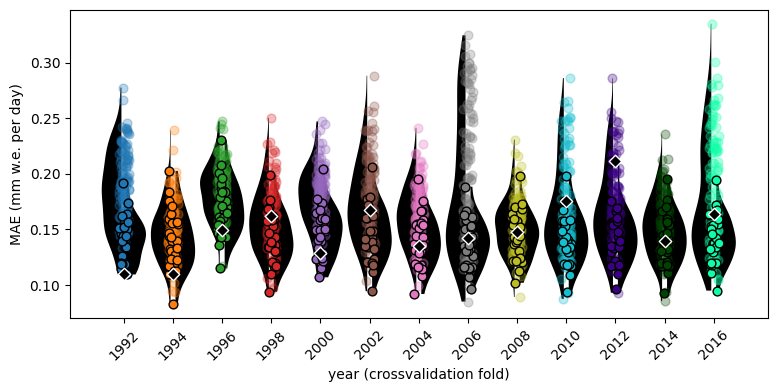

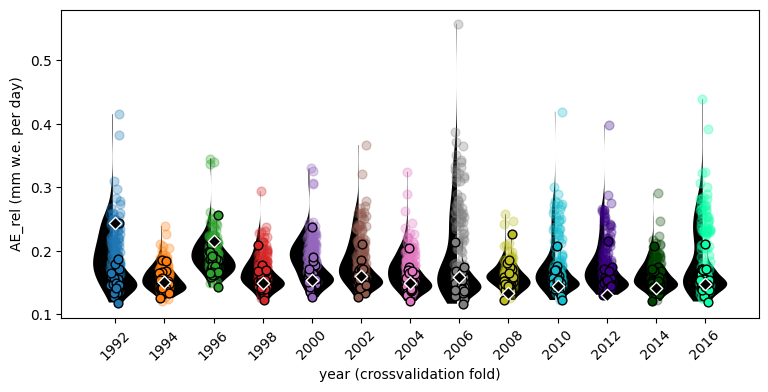

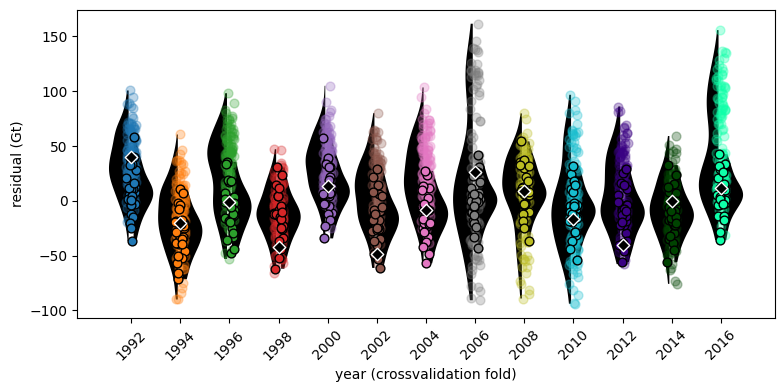

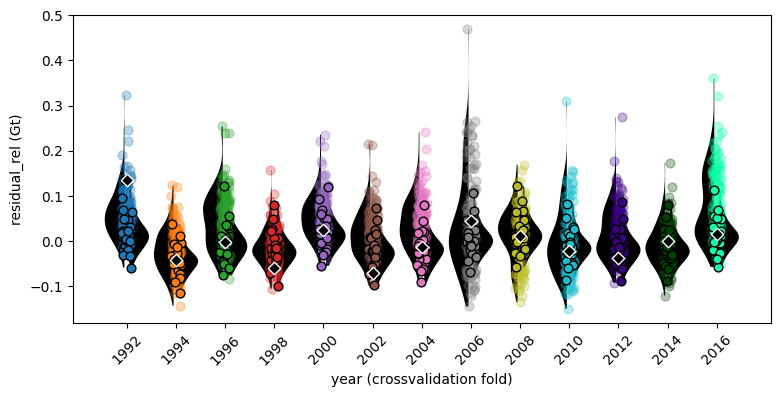

In [43]:
# Violinplots for all models vs best models

HIGHLIGHT = 'best_mae_allyears'    # or 'best_mbe', 'best_mbe_allyears', 'best_rmse'

import seaborn as sns
cmap = mcolors.ListedColormap(cc.glasbey_category10)
colors = cmap.colors

appliedyears = range(1990, 2017)
valyears = range(1992, 2017, 2)
# Plot of residuals per year in Gt

true_melt = df_per_year[df_per_year.index.get_level_values('iter') == 0][['true melt']].droplevel(level=[0,1])

metrics = ['MAE', 'AE_rel', 'residual', 'residual_rel']

for metric_to_plot in metrics:
    fig, ax = plt.subplots(figsize=(9,4))  
            
    for i,bb in enumerate(valyears):
        dff = df_per_year.xs(bb, level='valyear')[[metric_to_plot, HIGHLIGHT]]
        
        # vp = sns.boxplot(dff[metric_to_plot].values, positions=[i], showfliers=False, widths=0.6, fill=False, color='k', linewidth=1, ax=ax, zorder=1)
        if HIGHLIGHT == 'val':
            dff_nonh = dff[dff.index.get_level_values('appliedyear') != bb]
            dff_h = dff[dff.index.get_level_values('appliedyear') == bb]
        elif HIGHLIGHT in ['best_mbe', 'best_mbe_allyears', 'best_rmse', 'best_mae_allyears']:
            dff_nonh = dff[~dff[HIGHLIGHT]]
            dff_h = dff[dff[HIGHLIGHT]]
            dff_h_val = dff_h[dff_h.index.get_level_values('appliedyear') == bb]
        
        vp = ax.violinplot(dff[metric_to_plot].values, positions=[i-0.05], widths=0.8, showmedians=False, showextrema=False)
        for pc in vp['bodies']:
            pc.set_facecolor('k')
            pc.set_alpha(1.)  # 0.5 = 50% transparent
            verts = pc.get_paths()[0].vertices
            center = np.mean(verts[:, 0])      # x-center of violin
            verts[verts[:, 0] > center, 0] = center  # collapse left half to center
            
        vp = ax.violinplot(dff_h[metric_to_plot].values, positions=[i+0.05], widths=0.8, showmedians=False, showextrema=False)
        for pc in vp['bodies']:
            pc.set_facecolor('k')
            pc.set_alpha(1.)  # 0.5 = 50% transparent
            verts = pc.get_paths()[0].vertices
            center = np.mean(verts[:, 0])      # x-center of violin
            verts[verts[:, 0] < center, 0] = center  # collapse left half to center

        ax.scatter((np.random.rand(len(dff_nonh)))*0.2+i-0.1, dff_nonh[metric_to_plot].values, s=40, color=colors[i], alpha=0.3)
        ax.scatter((np.random.rand(len(dff_h)))*0.2+i-0.1, dff_h[metric_to_plot].values, s=40, color=colors[i], edgecolor='k', linewidth=1)
        ax.scatter([i]*len(dff_h_val), dff_h_val[metric_to_plot].values, marker='D', s=40, color='k', edgecolor='white', linewidth=1)

        ax.set_xticks(np.arange(len(valyears)))
        ax.set_xticklabels(valyears, rotation=45)
       

        if metric_to_plot=='R2':
            ax.set_ylabel('R$²$')
        elif metric_to_plot=='R2_anomalies':
            ax.set_ylabel('R$²_{anom}$')
        elif 'residual' in metric_to_plot:
            ax.set_ylabel(f'{metric_to_plot} (Gt)')
        else:
            ax.set_ylabel(metric_to_plot+' (mm w.e. per day)')
        ax.set_xlabel('year (crossvalidation fold)')
        
       # os.makedirs(os.path.sep.join([fig_dir, 'violinplots']), exist_ok=True)
       # fig.savefig(os.path.sep.join([fig_dir, 'violinplots', f"per_year_{metric_to_plot}_{HIGHLIGHT}.png"]), bbox_inches='tight', dpi=200)

    plt.show()

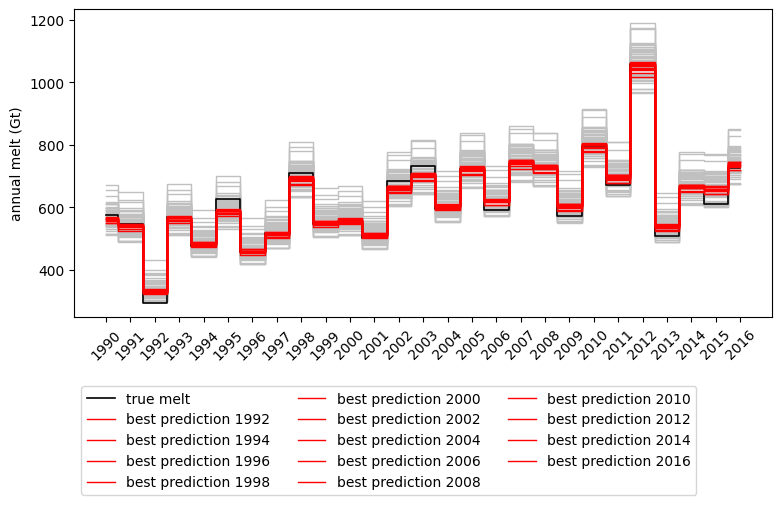

In [ ]:
# all the best models show under- or overestimation in the same years!
valyears = df_per_year.index.get_level_values('valyear').unique()
iters = df_per_year.index.get_level_values('iter').unique()
appliedyears = df_per_year.index.get_level_values('appliedyear').unique()

fig, ax = plt.subplots(figsize=(9,4))

true_melt = df_per_year[(df_per_year.index.get_level_values('iter') == 0) & (df_per_year.index.get_level_values('valyear') == df_per_year.index.get_level_values('valyear')[0])][['true melt']].droplevel(level=[0,1])
ax.step(x=range(len(true_melt)), y=true_melt.values, where='mid', color='k', linewidth=1.2, zorder=0, label='true melt')

for valyear in valyears:
    for it in iters:
        df_filter = df_per_year[(df_per_year.index.get_level_values('iter') == it) & (df_per_year.index.get_level_values('valyear') == valyear)].droplevel(level=[0,1])
        pred_melt = df_filter['predicted melt']
        best_model = df_filter['best_mbe_allyears'].unique()
        if best_model:
            color = 'red'
            zorder = 1
            label = f'best prediction {valyear}'
        else:
            color = 'silver'
            zorder = -1
            label = None
        ax.step(x=range(len(pred_melt)), y=pred_melt.values, where='mid', color=color, linewidth=1, zorder=zorder, label=label)
        
# ax.set_ylim((0, melt_max))
ax.set_ylabel('annual melt (Gt)')
ax.set_xticks(np.arange(len(appliedyears)))
ax.set_xticklabels(appliedyears, rotation=45)
plt.legend(loc='lower left', bbox_to_anchor=(0,-0.6), ncols=3)

#plt.savefig(os.path.sep.join([fig_dir, f"timeseries_melt_true_vs_pred.png"]), bbox_inches='tight', dpi=200)

plt.show()

## Performance of the best iterations

/tmp/ipykernel_1796795/3213715195.py:2: UserWarning: The palette list has more values (256) than needed (27), which may not be intended.
  sns.scatterplot(data=df_per_year.reset_index(), x='MBE', y='MAE', hue='appliedyear', palette=colors)


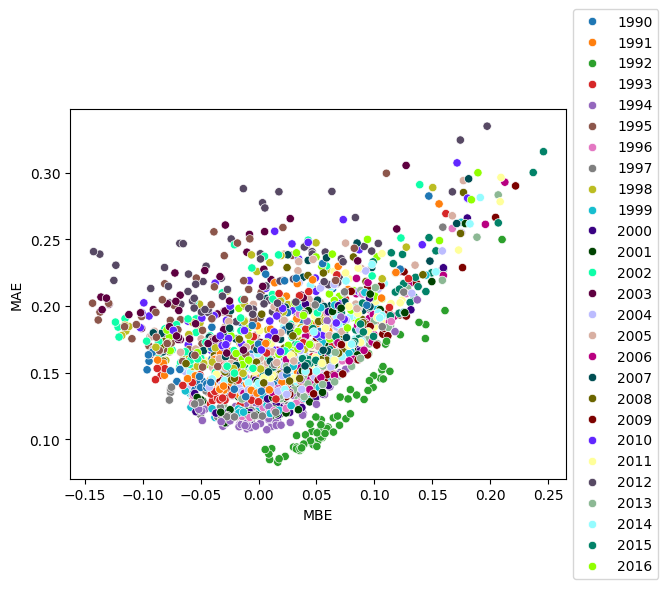

In [ ]:
## relationship between MAE and MBE for the different years and model folds:

# year 1992 is very different and forms its own little cluster in the MAE-MBE-space
sns.scatterplot(data=df_per_year.reset_index(), x='MBE', y='MAE', hue='appliedyear', palette=colors)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

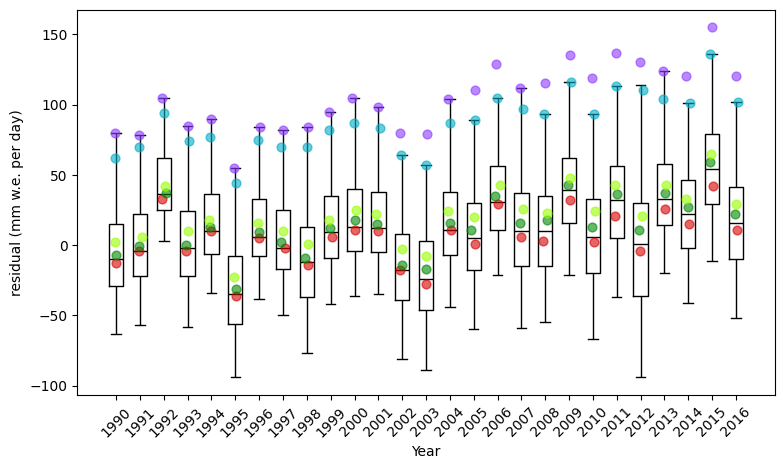

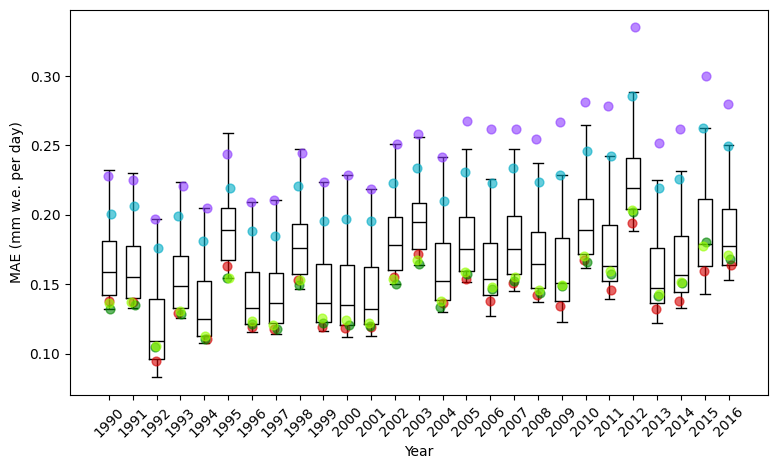

In [ ]:
# Show behaviour of one specific fold on all the years,
# the model realization overestimation melt on one year, overestimates on all of them --> model converged to a bad local minimum!
import seaborn as sns
cmap = mcolors.ListedColormap(cc.glasbey)
colors = cmap.colors

appliedyears = range(1990, 2017)
valyears = [2016]
iter_n = range(20)

for metric_to_plot in ['residual', 'MAE']:
    fig, ax = plt.subplots(figsize=(9,5))

    for i,bb in enumerate(appliedyears):
        dff = df_per_year.xs(bb, level='appliedyear')[metric_to_plot]
        vp = sns.boxplot(dff.values, positions=[i], showfliers=False, widths=0.6, fill=False, color='k', linewidth=1, ax=ax, zorder=-1)

        for it in iter_n:
            dff_train = dff[dff.index.get_level_values('iter') == it]
            for y in valyears:
                dff_year = dff_train[dff_train.index.get_level_values('valyear') == y]
                plt.scatter((np.random.rand(len(dff_year)))*0.2+i-0.1, dff_year.values, s=40, alpha=0.6, color=colors[it])

        ax.set_xticks(np.arange(len(appliedyears)))
        ax.set_xticklabels(appliedyears, rotation=45)

        if metric_to_plot=='R2':
            ax.set_ylabel('R$²$')
        elif metric_to_plot=='R2_anomalies':
            ax.set_ylabel('R$²_{anom}$')
        else:
            ax.set_ylabel(metric_to_plot+' (mm w.e. per day)')
        ax.set_xlabel('Year')

    plt.show()

In [ ]:
data_dir = os.path.sep.join([base_dir, 'data',  'processed', f'crossval', 'v_01', f'{DATA_SPEC}_meltNN_albedo', 'data.zarr'])
ds = xr.open_dataset(data_dir).sel(time=slice('01-01-1990', '12-31-2016'))

ds

In [ ]:
MODEL_SPEC = 'CESM2'
DATA_SPEC = 'CESM2'

pred_dir = os.path.sep.join([base_dir, 'output', f'crossval_{MODEL_SPEC}_modularNNEBM_log'])

if MODEL_SPEC == DATA_SPEC:
    FILE_SPEC = ''
else:
    FILE_SPEC = '_' + DATA_SPEC

year = 2016
ds_pred = xr.open_dataset(os.path.sep.join([pred_dir, f'fold_{year}', f'pred_data{FILE_SPEC}.zarr']))
ds_best = ds_pred.sel(iteration=16)
ds_best = ds_best.stack(z=('x', 'y')).reset_index('z').dropna(dim='z', how='all')
ds_best


import dask

var_names = ['albedom', 'dswrad']
years = [1992, 2016] # range(1990, 2017)

for var_name in var_names:
    for year in years:
        fig, ax = plt.subplots()
        plt.title(year)
        xx_da = ds.sel(time=slice(f'01-01-{year}', f'12-31-{year}'), variable_names=var_name).data.data.ravel()
        ds_best_year = ds_best.sel(time=slice(f'01-01-{year}', f'12-31-{year}'))
        yy_da = (ds_best_year['snmel_pred'] - ds_best_year['snmel_true']).data.ravel()

        xx, yy = dask.compute(xx_da, yy_da)
        hb = ax.hexbin(xx, yy, gridsize=100, bins='log', cmap='RdYlBu_r', linewidths=(0,), mincnt=1, vmin=1)
        plt.colorbar(hb)
        plt.ylabel('residual (mm w.e. per day)')
        plt.xlabel(var_name)
        plt.show()

In [ ]:
MODEL_SPEC = 'ERAI'
DATA_SPEC = 'CESM2'

pred_dir = os.path.sep.join([base_dir, 'output', f'crossval_{MODEL_SPEC}_modularNNEBM_log'])

if MODEL_SPEC == DATA_SPEC:
    FILE_SPEC = ''
else:
    FILE_SPEC = '_' + DATA_SPEC

year = 2016
ds_pred = xr.open_dataset(os.path.sep.join([pred_dir, f'fold_{year}', f'pred_data{FILE_SPEC}.zarr']))
ds_best = ds_pred.sel(iteration=17)
ds_best = ds_best.stack(z=('x', 'y')).reset_index('z').dropna(dim='z', how='all')
ds_best


import dask

var_names = ['albedom', 'dswrad']
years = [1992, 2016] # range(1990, 2017)

for var_name in var_names:
    for year in years:
        fig, ax = plt.subplots()
        plt.title(year)
        xx_da = ds.sel(time=slice(f'01-01-{year}', f'12-31-{year}'), variable_names=var_name).data.data.ravel()
        ds_best_year = ds_best.sel(time=slice(f'01-01-{year}', f'12-31-{year}'))
        yy_da = (ds_best_year['snmel_pred'] - ds_best_year['snmel_true']).data.ravel()

        xx, yy = dask.compute(xx_da, yy_da)
        hb = ax.hexbin(xx, yy, gridsize=100, bins='log', cmap='RdYlBu_r', linewidths=(0,), mincnt=1, vmin=1)
        plt.colorbar(hb)
        plt.ylabel('residual (mm w.e. per day)')
        plt.xlabel(var_name)
        plt.show()

In [ ]:
import numpy as np
from scipy.interpolate import UnivariateSpline

x = xx              # shape (N,)
r = yy           # shape (N,)
y = r**2

idx = np.argsort(x)
x_sorted = x[idx]
y_sorted = y[idx]

spl = UnivariateSpline(x_sorted, y_sorted, s=len(x_sorted)*np.var(y_sorted)*0.1)

y_fit = spl(x_sorted)
y_fit = np.clip(y_fit, 0, None)   # variance must be ≥ 0
sigma = np.sqrt(y_fit)



In [ ]:
sigma

In [ ]:
import matplotlib.pyplot as plt

def sigma_fn(x_new):
    return np.sqrt(np.clip(spl(x_new), 0, None))

plt.scatter(xx, yy, s=1, alpha=0.2)
plt.plot(x_sorted, y_fit, 'r')
#plt.plot(np.sort(xx), sigma_fn(np.sort(xx))**2, 'r')
plt.xlabel("SW radiation")
plt.ylabel("residual^2")

In [ ]:
import matplotlib.pyplot as plt

def sigma_fn(x_new):
    return np.sqrt(np.clip(spl(x_new), 0, None))

plt.scatter(xx, yy, s=1, alpha=0.2)
plt.plot(np.sort(xx), sigma_fn(np.sort(xx))**2, 'r')
plt.xlabel("SW radiation")
plt.ylabel("residual^2")